In [1]:
## Double check it wasn't possible to just do get_cehgear_at_gauge using IRIS

In [2]:
def get_cehgear_at_gauge (data_dir, x_coord, y_coord, rainfall_var, rain_gauge_name):
    
    filenames=[]
    general_filename = data_dir + f'*'
    for filename in glob.glob(general_filename):
        filenames.append(filename)
    
    # Extract the single point FIRST (cheap)
    rain_gauge_data = rain_meta_sf[rain_meta_sf['station_name']==rain_gauge_name]
    rain_gauge_data.reset_index(inplace=True, drop=True)
    
    x_val = float(rain_gauge_data['x_2'].iloc[0])
    y_val = float(rain_gauge_data['y_2'].iloc[0])

    # Find your x,y indices from the first file only
    with netCDF4.Dataset(filenames[0]) as nc:
        x_coord = nc.variables[x_coord][:]
        y_coord = nc.variables[y_coord][:]
        x_idx = np.abs(x_coord - x_val).argmin()
        y_idx = np.abs(y_coord - y_val).argmin()

    # Read just that pixel from every file
    all_data = []
    all_times = []

    for f in sorted(filenames):
        with netCDF4.Dataset(f) as nc:
            data = nc.variables[rainfall_var][:, y_idx, x_idx]  # (time,)
            data = np.where(data == -999.0, np.nan, data)
            data = np.where(data == -9999, np.nan, data)
            data = np.where(data < 0, np.nan, data)

            times = netCDF4.num2date(nc.variables['time'][:], nc.variables['time'].units)
            all_data.append(data)
            all_times.extend(times)

    # Combine
    rainfall = np.concatenate(all_data)
    times = np.array(all_times)

    # Build dataframe and aggregate
    df = pd.DataFrame({ 'time': times, 'rainfall': rainfall})
    df['date'] = pd.to_datetime([t.strftime('%Y-%m-%d %H:%M:%S') for t in df['time']])
    df['year'] = df['date'].dt.year
    df['date_only'] = df['date'].dt.date

    # Daily totals, then annual mean daily
    annual_hourly_mean = df.groupby('year')['rainfall'].mean().reset_index()
    annual_hourly_mean.columns = ['year', 'mean_daily_rainfall_mm']
    #annual_daily_mean = daily_totals.groupby('year')['rainfall'].mean().reset_index()
    #annual_daily_mean.columns = ['year', 'mean_hourly_rainfall_mm']

    annual_total = df.groupby('year')['rainfall'].sum().reset_index()
    annual_total.columns = ['year', 'total_rainfall_mm']
    return annual_total

def extract_annual_values (df, date_column, precip_column, source):
    # 1. Ensure datetime
    if source == 'NRW':
        df[date_column] = pd.to_datetime(df[date_column],dayfirst=True, format='mixed')
    elif source == 'ARW':
        df[date_column] = pd.to_datetime(df[date_column])
        
    # 2. Extract year
    df['year'] = df[date_column].dt.year

    # 3. Annual totals
    annual_rainfall = df.groupby('year')[precip_column].sum()
    
    # Convert to dataframe
    annual_rainfall_df=pd.DataFrame({"rainfall":annual_rainfall})
    annual_rainfall_df.reset_index(inplace=True)

    # 4. Mean annual rainfall
    mean_annual_rainfall = annual_rainfall.mean()

    return annual_rainfall_df

In [3]:
import pandas as pd
import pyreadr
import geopandas as gpd
import glob
import iris
import iris.coord_categorisation
import importlib
iris.FUTURE.date_microseconds = True
import netCDF4
import numpy as np
import glob

import functions
importlib.reload(functions)
from functions import *

data_dir = "/scratch/hydro4/users/kv25483/FDRI/Rain_gauge_optimisation/Data/"

In [4]:
# Load rain gauge metadata
rain_meta_cmd = pd.read_csv(data_dir + "rain_meta_for_CMD.csv")

# Convert to GeoDataFrame (BNG coordinates)
rain_meta_sf = gpd.GeoDataFrame(rain_meta_cmd, geometry=gpd.points_from_xy(rain_meta_cmd["x_2"], rain_meta_cmd["y_2"]),
                                crs="EPSG:27700")

### Get AWS rain gauge data for the Carreg and Tan gauges

In [5]:
rain_gauge = pd.read_csv(data_dir  + "RainGaugeData/Plynlimon/aws_hourly_qc.csv")
lookup = pd.read_csv(data_dir  + "RainGaugeData/Plynlimon/aws_site_metadata.csv")

carreg = rain_gauge[rain_gauge['id'].isin(['CW', 'CW2', 'CW3'])].copy()
tan = rain_gauge[rain_gauge['id'].isin(['TN', 'TN2', 'TN3', 'TW', 'TM'])].copy()

### Get NRW rain gauge data for the Dolydd and Nantgwynmain gauges

In [6]:
nrw_gauges = pyreadr.read_r(data_dir  + "RainGaugeData/NRW/NRW_rainfall_all.rds") # also works for RData
nrw_gauges = nrw_gauges[None] # extract the pandas data frame 

dolydd = nrw_gauges[nrw_gauges['station'].isin(['DOLYDD'])].copy()
nantgwynmain = nrw_gauges[nrw_gauges['station'].isin(['NANTGWYNMAIN'])].copy()

### Get MIDAS data

In [7]:
def extract_annual_values_midas(gauge_name):
    folder = data_dir + f"RainGaugeData/MIDAS - daily data/{gauge_name}/"
    all_files = sorted(glob.glob(folder + "*.csv"))

    dfs = []
    for f in all_files:
        df = pd.read_csv(f, skiprows=64)  # replace N
        df = df[df['ob_date'] != 'end data']
        df = df[['ob_date', 'prcp_amt']]  # replace with actual column names
        df['ob_date'] = pd.to_datetime(df['ob_date'])
        df['year'] = df['ob_date'].dt.year
        dfs.append(df)

    combined = pd.concat(dfs, ignore_index=True)
    combined = combined[combined['prcp_amt'] >= 0]  # drop fill values

    annual = combined.groupby('year')['prcp_amt'].sum().reset_index()
    annual.columns = ['year', 'rainfall']
    return annual

clywedog_annual_means = extract_annual_values_midas("CLywedog_16800")
llanidloes_annual_means = extract_annual_values_midas("Llanidloes_9659")

### Convert to annual values

In [8]:
carreg_annual_means = extract_annual_values(carreg, 'date_time', 'precipitation', 'ARW')
tan_annual_means = extract_annual_values(tan, 'date_time', 'precipitation', 'ARW')
nantgwynmain_annual_means = extract_annual_values(nantgwynmain, 'Time stamp', 'rain_mm', 'NRW')
dolydd_annual_means = extract_annual_values(dolydd, 'Time stamp', 'rain_mm', 'NRW')

### Get CEH-GEAR data from 1990 to 2016

In [9]:
had_uk_dir =  data_dir + "HAD_rainfall_annual/"  
ceh_gear_dir = "/scratch/hydro4/shared_data/climate_observed/CEH-GEAR/hourly/1km/"

DOLYDD_haduk = get_cehgear_at_gauge(had_uk_dir, 'projection_x_coordinate', 'projection_y_coordinate', 'rainfall', 'DOLYDD')
DOLYDD_cehgear = get_cehgear_at_gauge(ceh_gear_dir, 'x', 'y', 'rainfall_amount', 'DOLYDD')

In [10]:
NANTGWYNMAIN_haduk = get_cehgear_at_gauge(had_uk_dir, 'projection_x_coordinate', 'projection_y_coordinate', 'rainfall', 'NANTGWYNMAIN')
NANTGWYNMAIN_cehgear = get_cehgear_at_gauge(ceh_gear_dir, 'x', 'y', 'rainfall_amount', 'NANTGWYNMAIN')

In [11]:
CARREG_haduk = get_cehgear_at_gauge(had_uk_dir, 'projection_x_coordinate', 'projection_y_coordinate', 'rainfall', 'Carreg_2000')
CARREG_cehgear = get_cehgear_at_gauge(ceh_gear_dir, 'x', 'y', 'rainfall_amount', 'Carreg_2000')

TAN_haduk = get_cehgear_at_gauge(had_uk_dir, 'projection_x_coordinate', 'projection_y_coordinate', 'rainfall', 'Tan2')
TAN_cehgear = get_cehgear_at_gauge(ceh_gear_dir, 'x', 'y', 'rainfall_amount', 'Tan2')

In [12]:
CLYWEDOG_haduk = get_cehgear_at_gauge(had_uk_dir, 'projection_x_coordinate', 'projection_y_coordinate', 'rainfall', 'Clywedog')
CLYWEDOG_cehgear = get_cehgear_at_gauge(ceh_gear_dir, 'x', 'y', 'rainfall_amount', 'Clywedog')

In [13]:
LLANIDLOES_haduk = get_cehgear_at_gauge(had_uk_dir, 'projection_x_coordinate', 'projection_y_coordinate', 'rainfall', 'Llanidloes')
LLANIDLOES_cehgear = get_cehgear_at_gauge(ceh_gear_dir, 'x', 'y', 'rainfall_amount', 'Llanidloes')

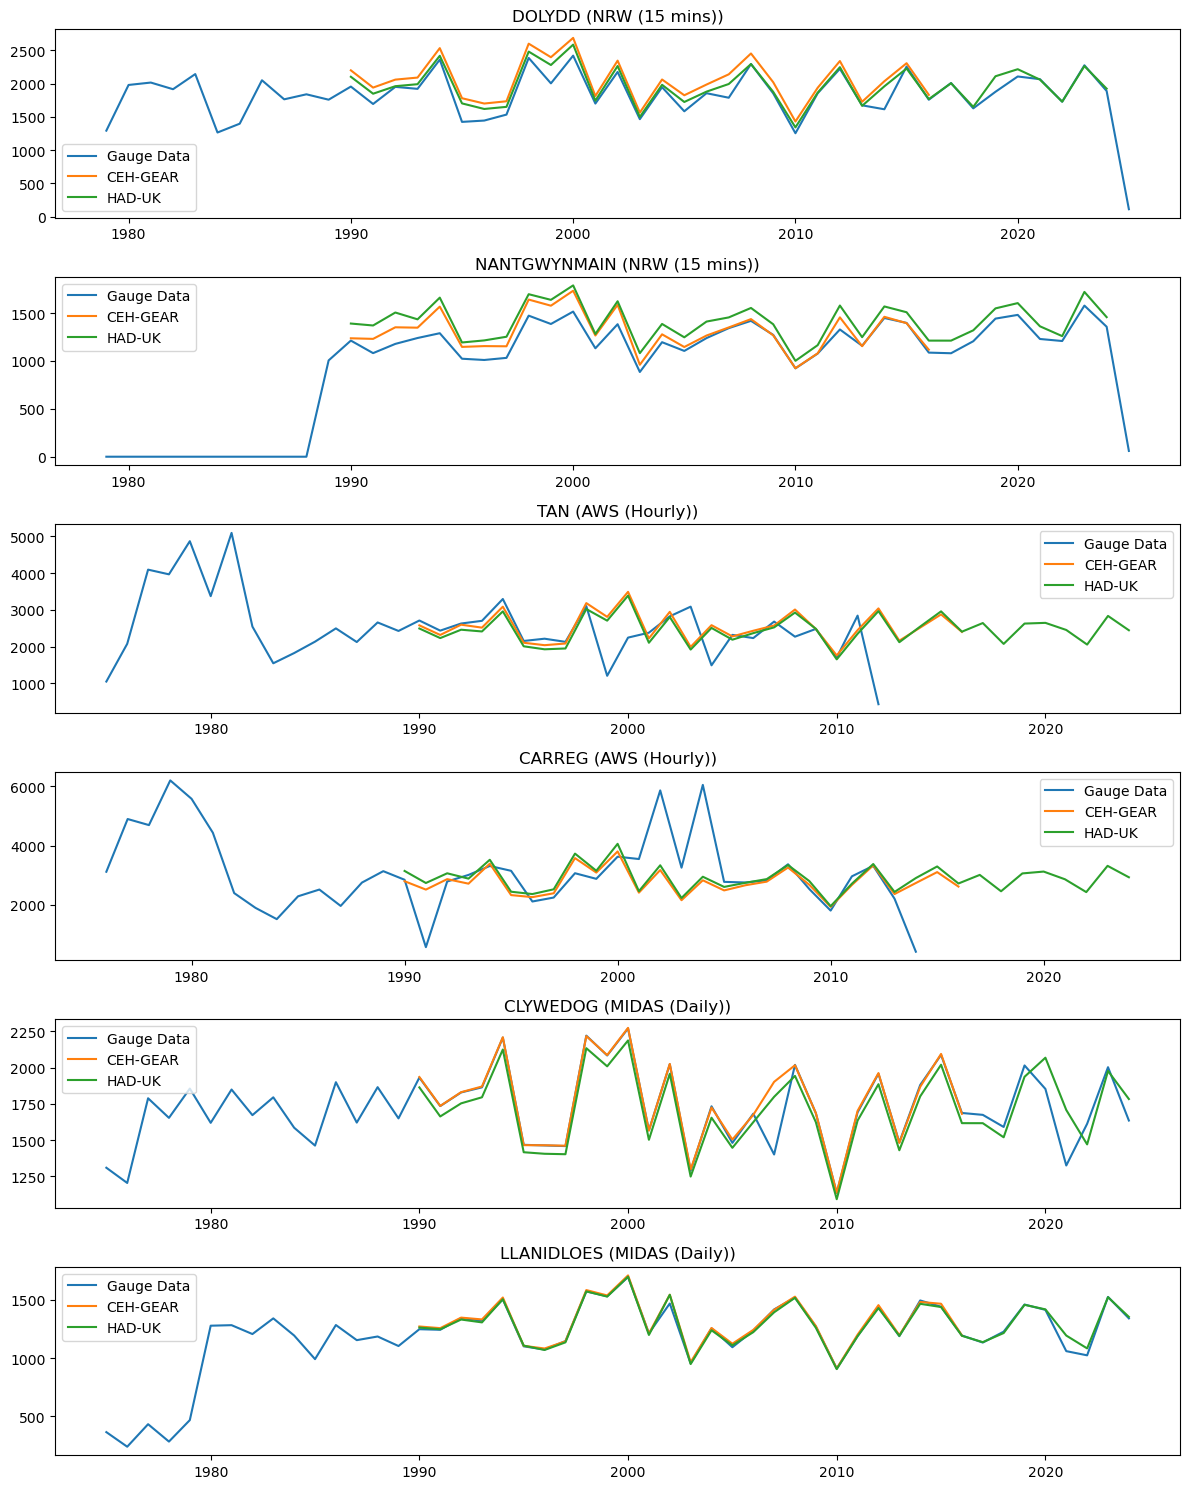

In [20]:
fig,axs=plt.subplots(nrows=6, figsize=(12,15))
def add_subplot(ax, gauge_name, data_source, annual_means, cehgear, haduk):
    ax.plot(annual_means['year'], annual_means['rainfall'], label='Gauge Data')
    ax.plot(cehgear['year'], cehgear['total_rainfall_mm'], label = 'CEH-GEAR')
    ax.plot(haduk['year'], haduk['total_rainfall_mm'], label = 'HAD-UK')
    ax.legend()
    ax.set_title(f"{gauge_name} ({data_source})")
    
add_subplot(axs[0], 'DOLYDD', 'NRW (15 mins)', dolydd_annual_means, DOLYDD_cehgear, DOLYDD_haduk )   
add_subplot(axs[1], 'NANTGWYNMAIN', 'NRW (15 mins)', nantgwynmain_annual_means, NANTGWYNMAIN_cehgear, NANTGWYNMAIN_haduk )   
add_subplot(axs[2], 'TAN', 'AWS (Hourly)', tan_annual_means, TAN_cehgear, TAN_haduk ) 
add_subplot(axs[3], 'CARREG','AWS (Hourly)',  carreg_annual_means, CARREG_cehgear, CARREG_haduk ) 
add_subplot(axs[4], 'CLYWEDOG', 'MIDAS (Daily)', clywedog_annual_means, CLYWEDOG_cehgear, CLYWEDOG_haduk )   
add_subplot(axs[5], 'LLANIDLOES','MIDAS (Daily)', llanidloes_annual_means, LLANIDLOES_cehgear, LLANIDLOES_haduk )   
fig.tight_layout()